# Final v1 Retrain Pipeline Notebook

Notebook ini dibuat untuk **sinkron** dengan pipeline terminal `src.final_v1.run_final_v1`.

Workflow yang disarankan:

1. Jalankan pipeline dari terminal terlebih dahulu.
2. Setelah semua output tersimpan di `results/final_v1/` dan `checkpoints/final_v1/`, buka notebook ini.
3. Tekan **Run All** untuk membaca, merangkum, dan memvisualisasikan hasil yang sama.

Dengan alur ini, notebook berfungsi sebagai **viewer + summary notebook**, bukan sumber hasil yang berbeda dari terminal.

## Referensi Hasil Terkunci

Target referensi untuk dibandingkan dengan hasil retrain:

- **Front14A**: Macro F1 `0.76626`, confusion `[[24, 16], [14, 166]]`
- **Side13**: Macro F1 `0.62023`, confusion `[[11, 29], [12, 168]]`
- **Average Fusion**: Macro F1 `0.78059`, confusion `[[20, 20], [4, 176]]`
- **Adaptive Fusion lama**: Macro F1 `0.78059`, confusion `[[20, 20], [4, 176]]`, diff vs average `0`

Karena ini adalah retraining deep learning, hasil aktual boleh berbeda sedikit. Notebook ini akan menghitung selisih terhadap referensi, bukan menimpa angka manual.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.final_v1.config_final_v1 import (
    CHECKPOINTS_DIR_FINAL,
    FRONT_CONFIG,
    REFERENCE_RESULTS,
    RESULTS_DIR_FINAL,
    SIDE_CONFIG,
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context('notebook')

print('Project root :', PROJECT_ROOT)
print('Results dir  :', RESULTS_DIR_FINAL)
print('Ckpt dir     :', CHECKPOINTS_DIR_FINAL)

Project root : D:\Skripsi\Experiment
Results dir  : D:\Skripsi\Experiment\results\final_v1
Ckpt dir     : D:\Skripsi\Experiment\checkpoints\final_v1


## Konfigurasi Pipeline Final

Cell berikut menampilkan konfigurasi front final dan side final yang saat ini dipakai oleh `src.final_v1.run_final_v1`.

In [2]:
front_cfg_df = pd.DataFrame([FRONT_CONFIG])
side_cfg_df = pd.DataFrame([SIDE_CONFIG])

display(front_cfg_df.T.rename(columns={0: 'front_final_config'}))
display(side_cfg_df.T.rename(columns={0: 'side_final_config'}))

,front_final_config
reference_name,Front14A revised
backbone,tf_efficientnetv2_s
pretrained,True
num_classes,2
learning_rate,0.00003
weight_decay,0.0003
dropout,0.4
label_smoothing,0.0
num_stages_to_freeze,5
scheduler,ReduceLROnPlateau


,side_final_config
reference_name,Side13
config_source,"[src/config.py, results/side_history.json, res..."
backbone,tf_efficientnetv2_s
pretrained,True
num_classes,2
learning_rate,0.00002
weight_decay,0.002
dropout,0.3
label_smoothing,0.0
num_stages_to_freeze,4


## Command Terminal yang Dipakai

Jalankan dari root repository `D:\\Skripsi\\Experiment`:

```powershell
python -m src.final_v1.run_final_v1
```

Varian lain:

```powershell
python -m src.final_v1.run_final_v1 --skip-train
python -m src.final_v1.run_final_v1 --view front
python -m src.final_v1.run_final_v1 --view side
```

Notebook ini **tidak akan menjalankan ulang training secara default** saat `Run All`.

In [3]:
# Optional helper: biarkan False agar Run All hanya membaca hasil terminal.
RUN_PIPELINE_FROM_NOTEBOOK = False

if RUN_PIPELINE_FROM_NOTEBOOK:
    import subprocess
    completed = subprocess.run(
        [sys.executable, '-m', 'src.final_v1.run_final_v1'],
        cwd=PROJECT_ROOT,
        check=True,
        text=True,
        capture_output=True,
    )
    print(completed.stdout)
else:
    print('RUN_PIPELINE_FROM_NOTEBOOK=False -> notebook hanya membaca artefak yang sudah dibuat dari terminal.')

RUN_PIPELINE_FROM_NOTEBOOK=False -> notebook hanya membaca artefak yang sudah dibuat dari terminal.


In [4]:
expected_files = {
    'front_history': RESULTS_DIR_FINAL / 'front_history_final_v1.json',
    'side_history': RESULTS_DIR_FINAL / 'side_history_final_v1.json',
    'front_train_summary': RESULTS_DIR_FINAL / 'front_train_summary_final_v1.json',
    'side_train_summary': RESULTS_DIR_FINAL / 'side_train_summary_final_v1.json',
    'front_metrics': RESULTS_DIR_FINAL / 'front_final_v1_metrics.json',
    'side_metrics': RESULTS_DIR_FINAL / 'side_final_v1_metrics.json',
    'single_view_predictions': RESULTS_DIR_FINAL / 'final_v1_single_view_predictions.csv',
    'fusion_metrics': RESULTS_DIR_FINAL / 'fusion_final_v1_metrics.json',
    'fusion_predictions': RESULTS_DIR_FINAL / 'fusion_final_v1_predictions.csv',
    'summary_json': RESULTS_DIR_FINAL / 'final_v1_summary.json',
    'summary_md': RESULTS_DIR_FINAL / 'final_v1_summary.md',
    'table_csv': RESULTS_DIR_FINAL / 'final_v1_table.csv',
    'front_checkpoint': CHECKPOINTS_DIR_FINAL / 'front_best_final_v1.pt',
    'side_checkpoint': CHECKPOINTS_DIR_FINAL / 'side_best_final_v1.pt',
}

exist_df = pd.DataFrame(
    [{'artifact': name, 'exists': path.exists(), 'path': str(path)} for name, path in expected_files.items()]
)
display(exist_df)

,artifact,exists,path
0,front_history,True,D:\Skripsi\Experiment\results\final_v1\front_h...
1,side_history,True,D:\Skripsi\Experiment\results\final_v1\side_hi...
2,front_train_summary,True,D:\Skripsi\Experiment\results\final_v1\front_t...
3,side_train_summary,True,D:\Skripsi\Experiment\results\final_v1\side_tr...
4,front_metrics,True,D:\Skripsi\Experiment\results\final_v1\front_f...
5,side_metrics,True,D:\Skripsi\Experiment\results\final_v1\side_fi...
6,single_view_predictions,True,D:\Skripsi\Experiment\results\final_v1\final_v...
7,fusion_metrics,True,D:\Skripsi\Experiment\results\final_v1\fusion_...
8,fusion_predictions,True,D:\Skripsi\Experiment\results\final_v1\fusion_...
9,summary_json,True,D:\Skripsi\Experiment\results\final_v1\final_v...


In [5]:
def read_json_if_exists(path):
    return json.loads(path.read_text(encoding='utf-8')) if path.exists() else None

front_history = read_json_if_exists(expected_files['front_history'])
side_history = read_json_if_exists(expected_files['side_history'])
front_train_summary = read_json_if_exists(expected_files['front_train_summary'])
side_train_summary = read_json_if_exists(expected_files['side_train_summary'])
front_metrics = read_json_if_exists(expected_files['front_metrics'])
side_metrics = read_json_if_exists(expected_files['side_metrics'])
fusion_metrics = read_json_if_exists(expected_files['fusion_metrics'])
single_view_predictions = pd.read_csv(expected_files['single_view_predictions']) if expected_files['single_view_predictions'].exists() else None

print('Front metrics loaded :', front_metrics is not None)
print('Side metrics loaded  :', side_metrics is not None)
print('Fusion metrics loaded:', fusion_metrics is not None)
print('Single-view predictions loaded:', single_view_predictions is not None)

Front metrics loaded : True
Side metrics loaded  : True
Fusion metrics loaded: True
Single-view predictions loaded: True


## Ringkasan Training

Best epoch dan validation Macro F1 akan muncul di bawah jika training summary sudah tersedia.

In [6]:
training_rows = []
for view_name, summary in [('front', front_train_summary), ('side', side_train_summary)]:
    if summary is None:
        continue
    training_rows.append({
        'view': view_name,
        'best_epoch': summary.get('best_epoch'),
        'best_validation_macro_f1': summary.get('best_validation_macro_f1'),
        'train_loss_at_best_epoch': summary.get('train_loss_at_best_epoch'),
        'validation_loss_at_best_epoch': summary.get('validation_loss_at_best_epoch'),
        'train_validation_loss_gap_at_best_epoch': summary.get('train_validation_loss_gap_at_best_epoch'),
    })

if training_rows:
    display(pd.DataFrame(training_rows).set_index('view'))
else:
    print('Training summary belum tersedia.')

,best_epoch,best_validation_macro_f1,train_loss_at_best_epoch,validation_loss_at_best_epoch,train_validation_loss_gap_at_best_epoch
view,,,,,
front,9,0.72581,0.47353,0.51736,0.04383
side,11,0.75000,0.50153,0.56022,0.05869


## Status Generalisasi

Tabel ini mengubah gap `validation_loss - train_loss` pada best epoch menjadi label diagnostik. Threshold bersifat heuristik dan mengikuti cara baca ablation: gap kecil dianggap `OK`, gap menengah `BORDERLINE`, gap besar `OVERFIT`, sedangkan `UNDERFIT` ditandai jika performa validation masih rendah dan loss training masih tinggi.

In [7]:
def classify_generalization_status(train_loss, val_loss, val_macro_f1):
    if train_loss is None or val_loss is None or val_macro_f1 is None:
        return 'N/A'
    gap = val_loss - train_loss
    if val_macro_f1 < 0.60 and train_loss > 0.60:
        return 'UNDERFIT'
    if gap > 0.15:
        return 'OVERFIT'
    if gap > 0.07:
        return 'BORDERLINE'
    return 'OK'

diagnostic_rows = []
for view_name, summary in [('front', front_train_summary), ('side', side_train_summary)]:
    if summary is None:
        continue
    train_loss = summary.get('train_loss_at_best_epoch')
    val_loss = summary.get('validation_loss_at_best_epoch')
    val_macro_f1 = summary.get('best_validation_macro_f1')
    gap = summary.get('train_validation_loss_gap_at_best_epoch')
    diagnostic_rows.append({
        'view': view_name,
        'best_epoch': summary.get('best_epoch'),
        'train_loss_best': train_loss,
        'val_loss_best': val_loss,
        'loss_gap': gap,
        'val_macro_f1_best': val_macro_f1,
        'generalization_status': classify_generalization_status(train_loss, val_loss, val_macro_f1),
    })

if diagnostic_rows:
    display(pd.DataFrame(diagnostic_rows).set_index('view'))
else:
    print('Belum ada training summary untuk menghitung status generalisasi.')

,best_epoch,train_loss_best,val_loss_best,loss_gap,val_macro_f1_best,generalization_status
view,,,,,,
front,9,0.47353,0.51736,0.04383,0.72581,OK
side,11,0.50153,0.56022,0.05869,0.75000,OK


## Ringkasan Test Single-View dan Fusion

In [8]:
metric_rows = []

if front_metrics:
    metric_rows.append({
        'method': 'front_single_view',
        'accuracy': front_metrics['accuracy'],
        'precision_macro': front_metrics['precision_macro'],
        'recall_macro': front_metrics['recall_macro'],
        'f1_macro': front_metrics['f1_macro'],
        'safe_to_phone': front_metrics['safe_to_phone'],
        'phone_to_safe': front_metrics['phone_to_safe'],
        'confusion_matrix': str(front_metrics['confusion_matrix']),
    })

if side_metrics:
    metric_rows.append({
        'method': 'side_single_view',
        'accuracy': side_metrics['accuracy'],
        'precision_macro': side_metrics['precision_macro'],
        'recall_macro': side_metrics['recall_macro'],
        'f1_macro': side_metrics['f1_macro'],
        'safe_to_phone': side_metrics['safe_to_phone'],
        'phone_to_safe': side_metrics['phone_to_safe'],
        'confusion_matrix': str(side_metrics['confusion_matrix']),
    })

if fusion_metrics:
    for method_name in ['average_fusion', 'adaptive_fusion']:
        item = fusion_metrics[method_name]
        metric_rows.append({
            'method': method_name,
            'accuracy': item['accuracy'],
            'precision_macro': item['precision_macro'],
            'recall_macro': item['recall_macro'],
            'f1_macro': item['f1_macro'],
            'safe_to_phone': item['safe_to_phone'],
            'phone_to_safe': item['phone_to_safe'],
            'confusion_matrix': str(item['confusion_matrix']),
        })

if metric_rows:
    display(pd.DataFrame(metric_rows).set_index('method'))
    if fusion_metrics:
        print('adaptive_different_from_average =', fusion_metrics['adaptive_different_from_average'])
else:
    print('Metrics belum tersedia.')

,accuracy,precision_macro,recall_macro,f1_macro,safe_to_phone,phone_to_safe,confusion_matrix
method,,,,,,,
front_single_view,0.86364,0.77183,0.76111,0.76626,16,14,"[[24, 16], [14, 166]]"
side_single_view,0.81364,0.66553,0.60417,0.62023,29,12,"[[11, 29], [12, 168]]"
average_fusion,0.89091,0.86565,0.73889,0.78059,20,4,"[[20, 20], [4, 176]]"
adaptive_fusion,0.89091,0.86565,0.73889,0.78059,20,4,"[[20, 20], [4, 176]]"


adaptive_different_from_average = 0


## Calibration Metrics: ECE dan Brier Score

ECE dan Brier Score dibaca dari JSON metrics jika tersedia. Jika belum tersedia, notebook menghitung ulang dari `final_v1_single_view_predictions.csv` agar tetap sinkron dengan output terminal yang sudah ada.

Status kalibrasi memakai threshold heuristik berikut: ECE `< 0.05` = `BAIK`, `0.05-0.10` = `CUKUP`, `> 0.10` = `BURUK`; Brier Score `< 0.10` = `BAIK`, `0.10-0.25` = `BORDERLINE`, `>= 0.25` = `BURUK`.

In [9]:
def compute_ece_binary_from_probs(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true, dtype=float)
    y_prob = np.asarray(y_prob, dtype=float)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for idx in range(n_bins):
        lo, hi = bin_edges[idx], bin_edges[idx + 1]
        if idx == n_bins - 1:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        bin_acc = y_true[mask].mean()
        bin_conf = y_prob[mask].mean()
        ece += (mask.sum() / len(y_prob)) * abs(bin_acc - bin_conf)
    return round(float(ece), 5)

def compute_brier_from_probs(y_true, y_prob):
    y_true = np.asarray(y_true, dtype=float)
    y_prob = np.asarray(y_prob, dtype=float)
    return round(float(np.mean((y_prob - y_true) ** 2)), 5)

def classify_ece_status(ece_value):
    if ece_value is None or pd.isna(ece_value):
        return 'N/A'
    if ece_value < 0.05:
        return 'BAIK'
    if ece_value <= 0.10:
        return 'CUKUP'
    return 'BURUK'

def classify_brier_status(brier_value):
    if brier_value is None or pd.isna(brier_value):
        return 'N/A'
    if brier_value < 0.10:
        return 'BAIK'
    if brier_value < 0.25:
        return 'BORDERLINE'
    return 'BURUK'

calibration_rows = []
for view_name, metrics in [('front', front_metrics), ('side', side_metrics)]:
    ece_value = metrics.get('ece_binary') if metrics is not None else None
    brier_value = metrics.get('brier_score') if metrics is not None else None
    source = 'metrics_json'
    if (ece_value is None or brier_value is None) and single_view_predictions is not None:
        view_df = single_view_predictions[single_view_predictions['view'] == view_name]
        if not view_df.empty:
            ece_value = compute_ece_binary_from_probs(view_df['true_label'], view_df['prob_phone'])
            brier_value = compute_brier_from_probs(view_df['true_label'], view_df['prob_phone'])
            source = 'computed_from_predictions_csv'
    if ece_value is None and brier_value is None:
        continue
    calibration_rows.append({
        'view': view_name,
        'ece_binary': ece_value,
        'ece_status': classify_ece_status(ece_value),
        'brier_score': brier_value,
        'brier_score_status': classify_brier_status(brier_value),
        'source': source,
    })

if calibration_rows:
    display(pd.DataFrame(calibration_rows).set_index('view'))
else:
    print('Belum ada metrics/predictions untuk menghitung ECE dan Brier Score.')


,ece_binary,ece_status,brier_score,brier_score_status,source
view,,,,,
front,0.12513,BURUK,0.11311,BORDERLINE,metrics_json
side,0.18263,BURUK,0.16537,BORDERLINE,metrics_json


## Perbandingan Dengan Referensi Terkunci

In [10]:
comparison_rows = []

mapping = {
    'front': front_metrics,
    'side': side_metrics,
    'average_fusion': fusion_metrics['average_fusion'] if fusion_metrics else None,
    'adaptive_fusion': fusion_metrics['adaptive_fusion'] if fusion_metrics else None,
}

for key, reference in REFERENCE_RESULTS.items():
    actual = mapping.get(key)
    if actual is None:
        continue
    comparison_rows.append({
        'target': key,
        'reference_f1': reference['macro_f1'],
        'actual_f1': actual['f1_macro'],
        'delta_f1': round(actual['f1_macro'] - reference['macro_f1'], 5),
        'reference_confusion': str(reference['confusion_matrix']),
        'actual_confusion': str(actual['confusion_matrix']),
    })

if comparison_rows:
    display(pd.DataFrame(comparison_rows).set_index('target'))
else:
    print('Belum ada cukup artefak untuk dibandingkan dengan referensi.')

,reference_f1,actual_f1,delta_f1,reference_confusion,actual_confusion
target,,,,,
front,0.76626,0.76626,0.0,"[[24, 16], [14, 166]]","[[24, 16], [14, 166]]"
side,0.62023,0.62023,0.0,"[[11, 29], [12, 168]]","[[11, 29], [12, 168]]"
average_fusion,0.78059,0.78059,0.0,"[[20, 20], [4, 176]]","[[20, 20], [4, 176]]"
adaptive_fusion,0.78059,0.78059,0.0,"[[20, 20], [4, 176]]","[[20, 20], [4, 176]]"


## Kurva Training

Jika file history tersedia, cell di bawah akan memplot train loss, val loss, dan validation Macro F1 untuk front dan side.

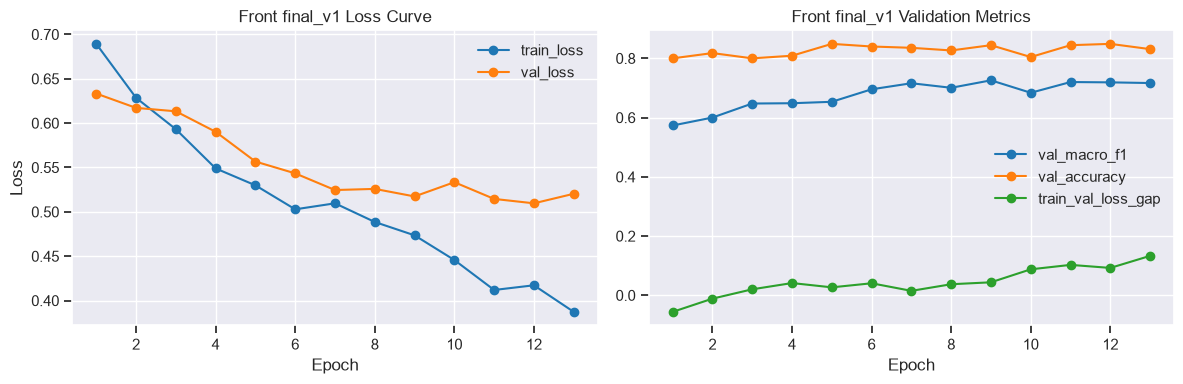

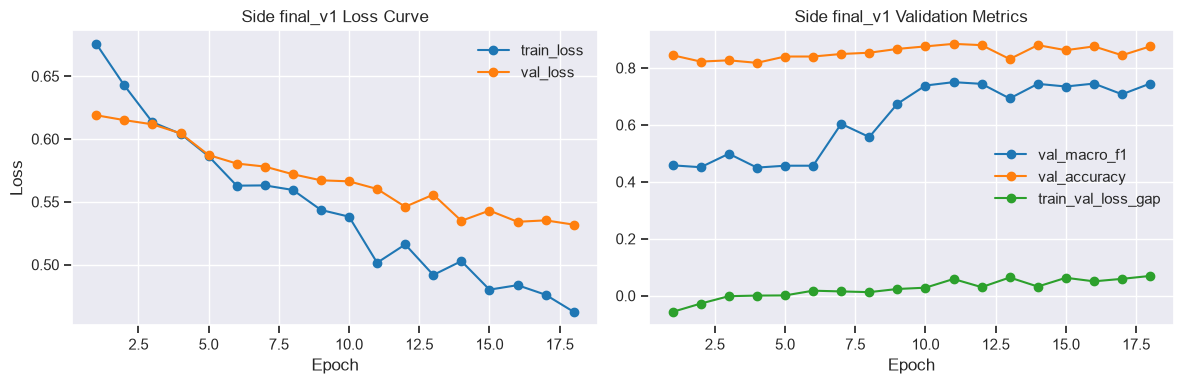

In [11]:
def plot_history(history, title_prefix):
    if history is None:
        print(f'History {title_prefix} belum tersedia.')
        return
    hist_df = pd.DataFrame(history)
    hist_df.index = hist_df.index + 1
    hist_df.index.name = 'epoch'

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    hist_df[['train_loss', 'val_loss']].plot(ax=axes[0], marker='o')
    axes[0].set_title(f'{title_prefix} Loss Curve')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')

    cols = [c for c in ['val_macro_f1', 'val_accuracy', 'train_val_loss_gap'] if c in hist_df.columns]
    hist_df[cols].plot(ax=axes[1], marker='o')
    axes[1].set_title(f'{title_prefix} Validation Metrics')
    axes[1].set_xlabel('Epoch')
    plt.tight_layout()
    plt.show()

plot_history(front_history, 'Front final_v1')
plot_history(side_history, 'Side final_v1')

## Visualisasi Confusion Matrix

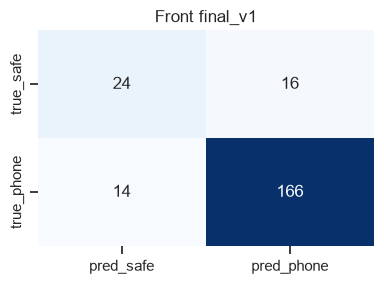

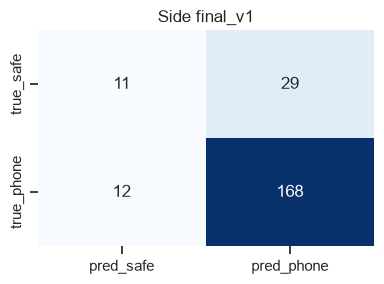

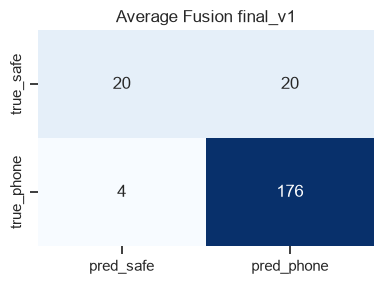

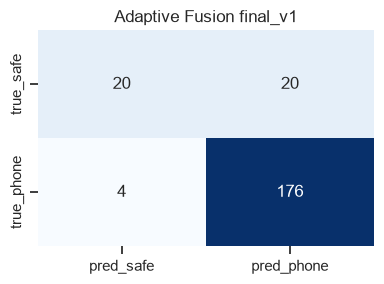

In [12]:
def plot_confusion(cm, title):
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(
        pd.DataFrame(cm, index=['true_safe', 'true_phone'], columns=['pred_safe', 'pred_phone']),
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax,
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

if front_metrics:
    plot_confusion(front_metrics['confusion_matrix'], 'Front final_v1')
if side_metrics:
    plot_confusion(side_metrics['confusion_matrix'], 'Side final_v1')
if fusion_metrics:
    plot_confusion(fusion_metrics['average_fusion']['confusion_matrix'], 'Average Fusion final_v1')
    plot_confusion(fusion_metrics['adaptive_fusion']['confusion_matrix'], 'Adaptive Fusion final_v1')

## Checklist Interpretasi

- Cek apakah **front retrain** masih mendekati referensi Front14A `0.76626`.
- Cek apakah **side retrain** masih mendekati referensi Side13 `0.62023`.
- Cek apakah **fusion** masih mengungguli single-view terbaik.
- Cek apakah **adaptive fusion** tetap identik dengan average fusion atau mulai berbeda.
- Jika hasil berbeda, catat bahwa retrain deep learning dapat berubah karena random seed, CUDA nondeterminism, augmentasi, dan early stopping.
- Jangan otomatis mengganti klaim final utama hanya karena satu run retrain berbeda dari referensi terkunci.